<a href="https://colab.research.google.com/github/alibaba35t/Content-Engagement-Optimizer/blob/main/view_engagement_optimizer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset
import torch
import torch.nn as nn
import os
from torch.optim.lr_scheduler import ReduceLROnPlateau


In [12]:
df = pd.read_csv("/content/Instagram_Analytics_organized.csv")
df = df.drop(columns=df.columns[df.columns.str.contains('^Unnamed')])

X = df.drop(columns="target").astype(np.float32)
y = df["target"].astype(np.float32)

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train = torch.FloatTensor(X_train_scaled)
y_train = torch.FloatTensor(y_train.values).unsqueeze(1)

X_test = torch.FloatTensor(X_test_scaled)
y_test = torch.FloatTensor(y_test.values).unsqueeze(1)


train_dataset = TensorDataset(X_train,y_train)
train_loader = DataLoader(train_dataset, batch_size=64,shuffle=True)

input_dimension = X_train.shape[1]

print(df["target"].value_counts())

target
0    22499
1     7500
Name: count, dtype: int64


In [13]:
class ViewPredictorModel(nn.Module):
  def __init__(self,input_dimension):
    super(ViewPredictorModel, self).__init__()
    self.layer_1 = nn.Linear(input_dimension,128)
    self.bn1 = nn.BatchNorm1d(128)

    self.layer_2 = nn.Linear(128,64)
    self.bn2 = nn.BatchNorm1d(64)

    self.layer_3 = nn.Linear(64,1)

    self.relu = nn.ReLU()
    self.sigmoid = nn.Sigmoid()
    self.dropout = nn.Dropout(p = 0.2)

  def forward(self, x):
    x = self.relu(self.bn1(self.layer_1(x)))
    x = self.dropout(x)
    x = self.relu(self.bn2(self.layer_2(x)))
    x = self.dropout(x)
    x = self.layer_3(x)
    return x

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


model = ViewPredictorModel(input_dimension=input_dimension).to(device)

pos_weight_value = 22499.0 / 7500.0  # ~3.0
pos_weight = torch.tensor([pos_weight_value], dtype=torch.float32).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

In [14]:
os.makedirs("model_checkpoints", exist_ok=True)


In [23]:
epochs = 100

for epoch in range(epochs):
  model.train()
  epoch_loss = 0
  for batch_X, batch_y in train_loader:

        batch_X, batch_y = batch_X.to(device), batch_y.to(device)

        optimizer.zero_grad()

        outputs = model(batch_X)

        loss = criterion(outputs, batch_y)

        loss.backward()

        optimizer.step()

        epoch_loss += loss.item()
  avg_loss = epoch_loss / len(train_loader)
  model.eval()
  val_loss = 0
  with torch.no_grad():

        val_outputs = model(X_test.to(device))
        val_loss = criterion(val_outputs, y_test.to(device)).item()


  scheduler.step(val_loss)

  if (epoch + 1) % 5 == 0 or epoch == 0:


      print(f"train loss:{avg_loss:.4f}| test loss{val_loss:.4f}")

      checkpoint_path = f"model_checkpoints/model_epoch_{epoch+1:02d}.pt"

      torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': avg_loss,
      }, checkpoint_path)


train loss:0.9910| test loss1.0727
train loss:0.9916| test loss1.0737
train loss:0.9922| test loss1.0717
train loss:0.9947| test loss1.0726
train loss:0.9928| test loss1.0730
train loss:0.9911| test loss1.0733
train loss:0.9902| test loss1.0740
train loss:0.9929| test loss1.0727
train loss:0.9911| test loss1.0726
train loss:0.9881| test loss1.0733
train loss:0.9936| test loss1.0729
train loss:0.9903| test loss1.0734
train loss:0.9912| test loss1.0727
train loss:0.9965| test loss1.0715
train loss:0.9948| test loss1.0735
train loss:0.9913| test loss1.0731
train loss:0.9937| test loss1.0721
train loss:0.9940| test loss1.0734
train loss:0.9915| test loss1.0729
train loss:0.9949| test loss1.0743
train loss:0.9932| test loss1.0730


In [26]:
loaded_model = ViewPredictorModel(input_dimension=X_test.shape[1]).to(device)


checkpoint_path = "model_checkpoints/model_epoch_90.pt"


checkpoint = torch.load(checkpoint_path, map_location=device)


loaded_model.load_state_dict(checkpoint['model_state_dict'])


loaded_model.eval()

X_test_tensor = X_test.to(device)
y_test_tensor = y_test.to(device)

with torch.no_grad():


    raw_predictions = loaded_model(X_test_tensor)


    probabilities = torch.sigmoid(raw_predictions)


    predicted_classes = (probabilities >= 0.5).float()


    correct_predictions = (predicted_classes == y_test_tensor).sum().item()
    total_samples = y_test_tensor.size(0)

    accuracy = (correct_predictions / total_samples) * 100

print("=========================================")
print(f"{accuracy:.2f}")
print("=========================================")

50.63


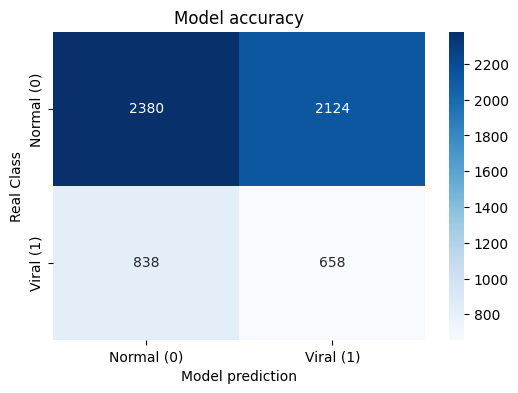

              precision    recall  f1-score   support

      Normal       0.74      0.53      0.62      4504
       Viral       0.24      0.44      0.31      1496

    accuracy                           0.51      6000
   macro avg       0.49      0.48      0.46      6000
weighted avg       0.61      0.51      0.54      6000



In [27]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

with torch.no_grad():
    logits = loaded_model(X_test_tensor.to(device))
    raw_predictions = torch.sigmoid(logits)
    predicted_classes = (raw_predictions >= 0.5).float().cpu().numpy()
    actual_classes = y_test_tensor.cpu().numpy()


cm = confusion_matrix(actual_classes, predicted_classes)


plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Normal (0)", "Viral (1)"],
            yticklabels=["Normal (0)", "Viral (1)"])
plt.ylabel('Real Class')
plt.xlabel('Model prediction')
plt.title('Model accuracy')
plt.show()


print(classification_report(actual_classes, predicted_classes, target_names=["Normal", "Viral"]))

XGBoost scale_pos_weight value: 3.00

================ XGBOOST PERFORMANCE ================
              precision    recall  f1-score   support

      Normal       0.75      0.56      0.64      4504
       Viral       0.25      0.45      0.33      1496

    accuracy                           0.53      6000
   macro avg       0.50      0.51      0.48      6000
weighted avg       0.63      0.53      0.56      6000



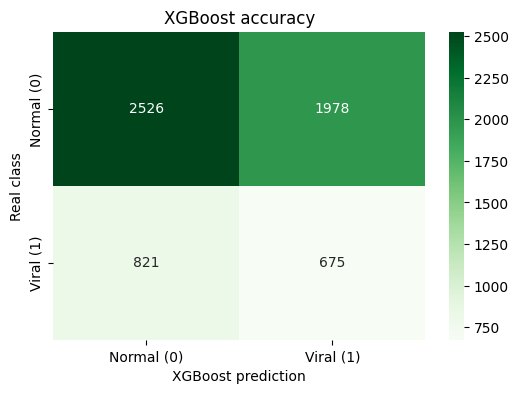

In [28]:


from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


X_train_np = X_train.cpu().numpy()
y_train_np = y_train.cpu().numpy().ravel()

X_test_np = X_test.cpu().numpy()
y_test_np = y_test.cpu().numpy().ravel()


num_neg = (y_train_np == 0).sum()
num_pos = (y_train_np == 1).sum()
scale_pos_weight_value = num_neg / num_pos

print(f"XGBoost scale_pos_weight value: {scale_pos_weight_value:.2f}")


xgb_model = XGBClassifier(
    n_estimators=150,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight_value,
    random_state=42,
    eval_metric='logloss'
)


xgb_model.fit(X_train_np, y_train_np)



y_pred = xgb_model.predict(X_test_np)


print("\n================ XGBOOST PERFORMANCE ================")
print(classification_report(y_test_np, y_pred, target_names=["Normal", "Viral"]))
print("=====================================================")


cm = confusion_matrix(y_test_np, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Normal (0)", "Viral (1)"],
            yticklabels=["Normal (0)", "Viral (1)"])
plt.ylabel('Real class')
plt.xlabel('XGBoost prediction')
plt.title('XGBoost accuracy')
plt.show()